# RBIG Walk-Through

This notebook walks through the RBIG algorithm step by step using the new
composable API.  The RBIG algorithm consists of two repeated steps:

1. **Marginal Gaussianization** — map each feature independently to N(0, 1)
   via the empirical CDF and probit transform.
2. **Rotation (PCA)** — decorrelate the Gaussianized features via a PCA
   rotation, which also whitens the data.

Repeating these two steps iteratively drives the joint distribution towards a
standard multivariate Gaussian.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from rbig import AnnealedRBIG, MarginalGaussianize, PCARotation, RBIGLayer

plt.style.use("seaborn-v0_8-paper")

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_2d_joint(data, title="Data", color="steelblue"):
    _fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.5, color=color)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

## Data

We generate a 2-D "sin-wave" dataset — a non-Gaussian joint distribution with
visible nonlinear dependence.

Data shape: (2000, 2)


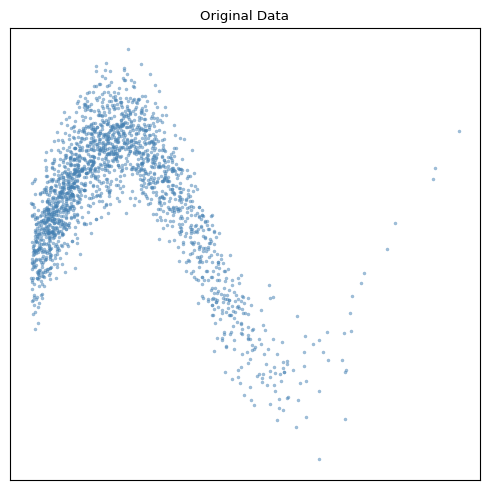

In [3]:
seed = 123
rng = np.random.RandomState(seed=seed)

num_samples = 2_000
x = np.abs(2 * rng.randn(1, num_samples))
y = np.sin(x) + 0.25 * rng.randn(1, num_samples)
data = np.vstack((x, y)).T

print(f"Data shape: {data.shape}")
plot_2d_joint(data, title="Original Data")

## Step I — Marginal Gaussianization

We use `MarginalGaussianize` to transform each feature independently to
approximately standard Gaussian using the empirical CDF + probit.

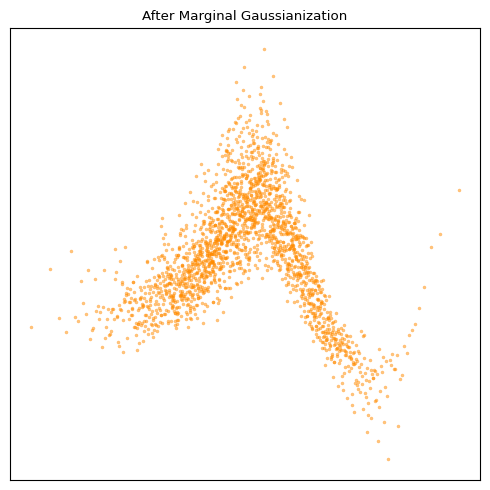

In [4]:
mg = MarginalGaussianize()
mg.fit(data)
data_mg = mg.transform(data)

plot_2d_joint(data_mg, title="After Marginal Gaussianization", color="darkorange")

After this step each marginal is approximately Gaussian, but the joint
distribution still shows dependence (the scatter plot is not circular).

## Step II — Rotation (PCA)

We apply `PCARotation` with whitening to decorrelate the Gaussianized features.

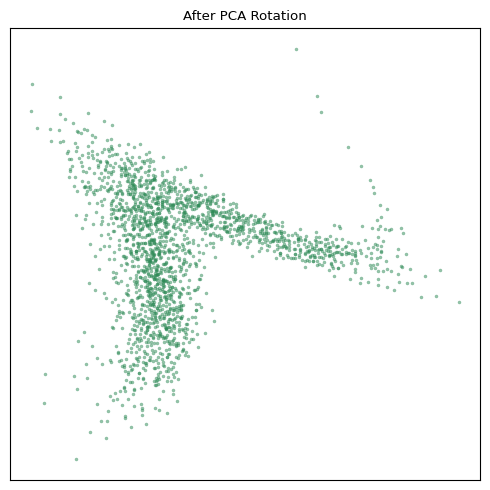

In [5]:
pca_rot = PCARotation(whiten=True)
pca_rot.fit(data_mg)
data_rot = pca_rot.transform(data_mg)

plot_2d_joint(data_rot, title="After PCA Rotation", color="seagreen")

One RBIG layer (marginal Gaussianization + rotation) has already significantly
reduced the dependence.  However, for strongly non-Gaussian data we need many
layers.

## Single RBIG Layer with `RBIGLayer`

The two steps above are packaged into a single `RBIGLayer`.

In [6]:
layer = RBIGLayer(
    marginal=MarginalGaussianize(),
    rotation=PCARotation(whiten=True),
)
layer.fit(data)
data_layer = layer.transform(data)

# Verify that RBIGLayer produces a transform with similar statistics
mean_manual = np.mean(data_rot, axis=0)
mean_layer = np.mean(data_layer, axis=0)
cov_manual = np.cov(data_rot, rowvar=False)
cov_layer = np.cov(data_layer, rowvar=False)

np.testing.assert_allclose(mean_layer, mean_manual, rtol=1e-3, atol=1e-3)
np.testing.assert_allclose(cov_layer, cov_manual, rtol=1e-3, atol=1e-3)
print(
    "RBIGLayer output has similar mean and covariance to manual marginal + rotation steps ✓"
)

RBIGLayer output has similar mean and covariance to manual marginal + rotation steps ✓


### Inverse transform

`RBIGLayer` is an invertible transform: we can map the Gaussianized data back
to the original space.

In [7]:
data_reconstructed = layer.inverse_transform(data_layer)
residual = np.abs(data - data_reconstructed).mean()
print(f"Mean absolute reconstruction error: {residual:.4e}")

Mean absolute reconstruction error: 1.0400e-03


## Full RBIG Model with `AnnealedRBIG`

`AnnealedRBIG` stacks many `RBIGLayer` instances and iterates until the total
correlation (TC) converges.

In [8]:
rbig_model = AnnealedRBIG(
    n_layers=50,
    rotation="pca",
    patience=10,
    random_state=seed,
)
rbig_model.fit(data)

print(f"Number of layers fitted: {len(rbig_model.layers_)}")

Number of layers fitted: 27


### Transformed data

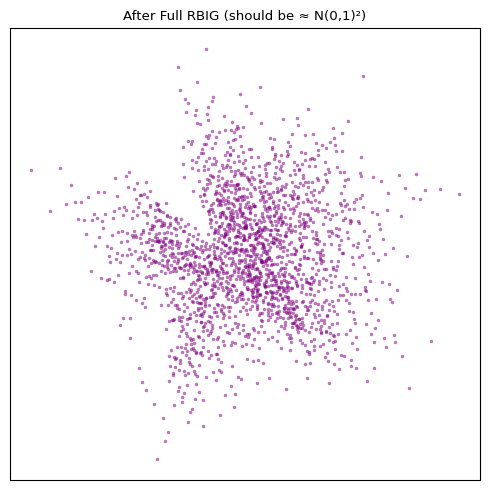

In [9]:
data_gauss = rbig_model.transform(data)
plot_2d_joint(data_gauss, title="After Full RBIG (should be ≈ N(0,1)²)", color="purple")

### Total correlation per layer

`tc_per_layer_` records the total correlation of the data **after** each layer.
It should decrease monotonically towards zero as the algorithm drives the data
towards a factorial Gaussian.

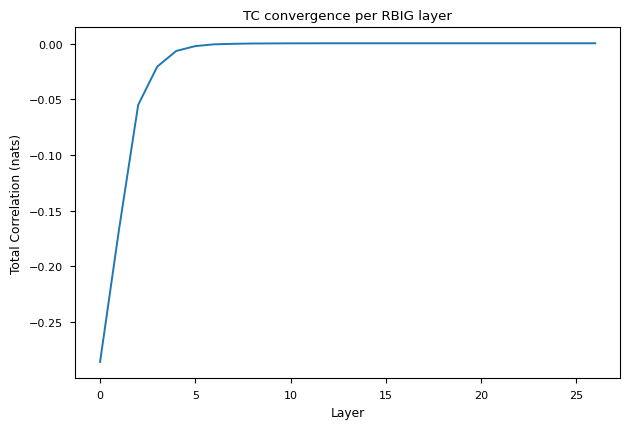

In [10]:
fig, ax = plt.subplots()
ax.plot(rbig_model.tc_per_layer_)
ax.set_xlabel("Layer")
ax.set_ylabel("Total Correlation (nats)")
ax.set_title("TC convergence per RBIG layer")
plt.tight_layout()
plt.show()

### Inverse transform (reconstruction)

In [11]:
data_inv = rbig_model.inverse_transform(data_gauss)
residual_full = np.abs(data - data_inv).mean()
print(f"Full RBIG mean absolute reconstruction error: {residual_full:.4e}")

Full RBIG mean absolute reconstruction error: 2.5275e-02


## Summary

The RBIG algorithm implemented in the new API:

| Class | Role |
|---|---|
| `MarginalGaussianize` | Marginal Gaussianization via empirical CDF + probit |
| `PCARotation` | Whitening PCA rotation |
| `RBIGLayer` | One RBIG layer = marginal + rotation |
| `AnnealedRBIG` | Full iterative model with convergence detection |